# Build HurryWave Model
This notebook builds a HurryWave model for the Caribbean region.

In [1]:
import os
from pprint import pprint
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

import hydromt
from hydromt_hurrywave import HurrywaveModel

## Initialize model

In [2]:
root_folder = Path(r'p:\11212696-fhics-bes\1_models\HurryWave\01_modelsetup\hurrywave_caribbean_v4')

hw = HurrywaveModel(
    root=root_folder,
    mode="w+"
)

2026-04-10 10:04:13,630 - hydromt.model.model - model - INFO - Initializing hurrywave model from hydromt_hurrywave (v0.1.0).
2026-04-10 10:04:13,631 - hydromt.model.model - model - WARNING - No region component found in components.


## Define region and refinement polygons

In [3]:
region_gdf = gpd.read_file(r"p:\11212696-fhics-bes\1_models\HurryWave\00_data\caribbean_inlcude.geojson")
refinement_polygons = gpd.read_file(r"p:\11212696-fhics-bes\1_models\HurryWave\00_data\refinement_1_v2.geojson").explode()

gdf_1 = gpd.GeoDataFrame(geometry=refinement_polygons.buffer(0.04))
gdf_1["refinement_level"] = 1

gdf_2 = refinement_polygons
gdf_2["refinement_level"] = 2

gdf_all = gpd.GeoDataFrame(pd.concat([gdf_1, gdf_2], ignore_index=True), crs=gdf_1.crs)

## Create quadtree grid

In [4]:
hw.quadtree_grid.create_from_region(
    region={"geom": region_gdf},
    res=1,
    refinement_polygons=gdf_all,
    crs=4326
)

Refining ...
Time elapsed : 0.5900347232818604 s
Finding neighbors ...
Time elapsed : 0.0013871192932128906 s
Setting neighbors left and below ...
Time elapsed : 0.0036737918853759766 s
Getting uv points ...
Time elapsed : 0.001363515853881836 s
Making XUGrid ...
Got rid of duplicates in 0.0052 seconds
Made XUGrid in 0.0001 seconds


In [5]:
hw.quadtree_grid.data.mask.ugrid.to_geodataframe().to_file(root_folder / "quadtree_grid.gpkg", driver="GPKG")

## Add elevation

In [6]:
elevation_list = [
    {"elevation": r"p:\11212696-fhics-bes\0_data\destination_earth\caribbean_2022_mean.tif"},
    {"elevation": r"c:\data\HurryWave\gebco_2024_n30.0_s0.0_w-80.0_e-40.0.tif"}
]

hw.quadtree_elevation.create(
    elevation_list=elevation_list,
)

2026-04-10 10:04:25,719 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading caribbean_2022_mean.tif RasterDataset data from p:\11212696-fhics-bes\0_data\destination_earth\caribbean_2022_mean.tif
2026-04-10 10:04:27,220 - hydromt.data_catalog.adapters.rasterdataset - rasterdataset - WARNING - Dataset [-70.5, 11.0, -59.5, 19.0] does not fully cover bbox [-75.000, 7.000, -54.000, 22.000]
2026-04-10 10:04:27,224 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco_2024_n30.0_s0.0_w-80.0_e-40.0.tif RasterDataset data from c:\data\HurryWave\gebco_2024_n30.0_s0.0_w-80.0_e-40.0.tif
2026-04-10 10:04:27,266 - hydromt.data_catalog.data_catalog - data_catalog - WARNING - overwriting data source 'caribbean_2022_mean.tif' with provider user and version _UNSPECIFIED_.
2026-04-10 10:04:27,268 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading caribbean_2022_mean.tif RasterDataset data from p:\11212696-fhics-bes\0_data\destination_

## Create mask

In [7]:
hw.quadtree_mask.create(zmax=0.0)

2026-04-10 10:04:30,244 - hydromt.hydromt_hurrywave.components.quadtree.quadtree_mask - quadtree_mask - INFO - Building HurryWave mask ...


## Add observation points

In [8]:
gdf_obs = gpd.read_file(r"p:\11212696-fhics-bes\1_models\HurryWave\00_data\observation_points.geojson")
hw.observation_points.add_points(gdf_obs)

## Update model configuration

In [9]:
hw.config.update(
    {
        "tref": "20170917 000000",
        "tstart": "20170917 000000",
        "tstop": "20170921 000000",
        "amufile": "hurrywave.amu",
        "amvfile": "hurrywave.amv",
        "outputformat": "net"
    }
)

## Add wave blocking

## Debug: wave blocking inline

Inline copy of `HurrywaveWaveBlocking.create` + `_Cell` for interactive debugging and plotting.
Run the setup cells above first (through quadtree mask), then step through these cells.
When done, delete or skip these cells and use `hw.wave_blocking.create(...)` as normal.

In [12]:
fn_line= r"c:\data\HurryWave\coastlines_caribbean.geojson"
gdf_line = gpd.read_file(fn_line)

hw.wave_blocking.create(
    #elevation_list=elevation_list,
    coastline_gdf=gdf_line,
    quiet=False
)

2026-04-10 10:08:10,386 - hydromt.hydromt_hurrywave.components.quadtree.wave_blocking - wave_blocking - INFO - Wave-blocking: 108 cells with obstacles above threshold.


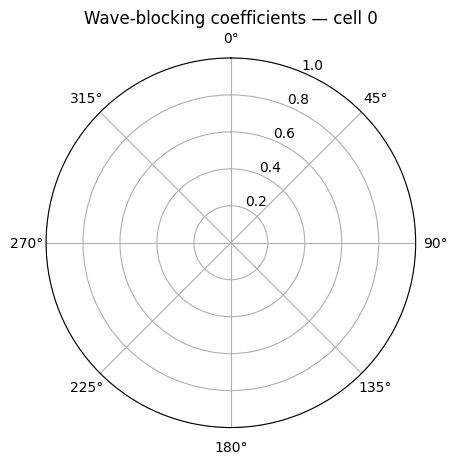

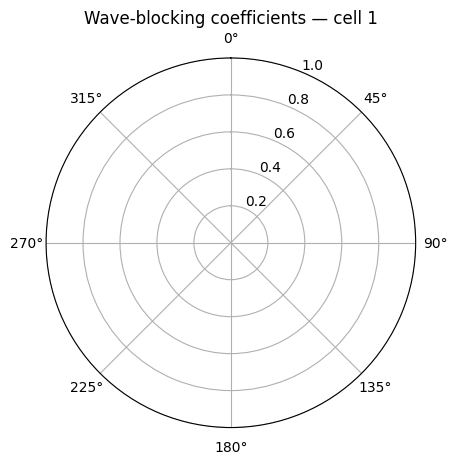

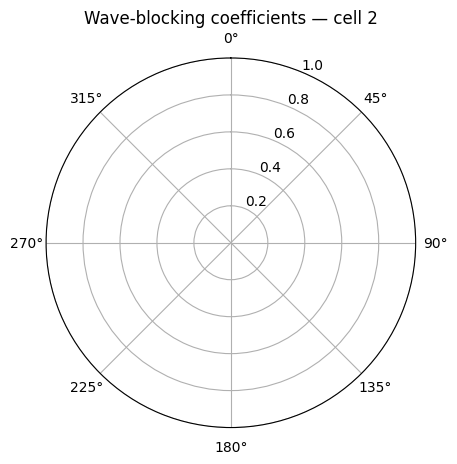

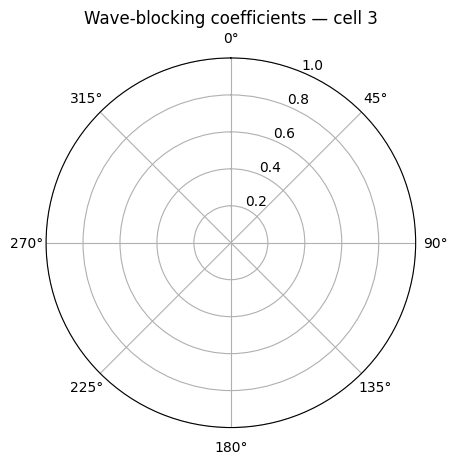

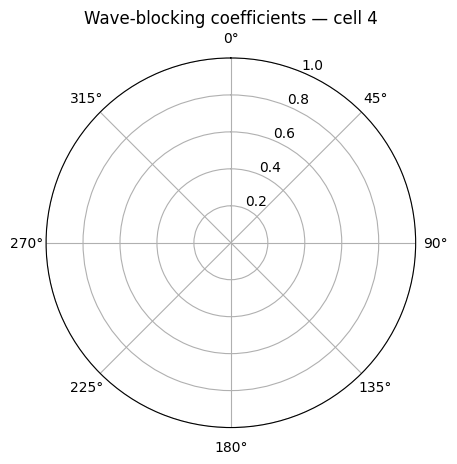

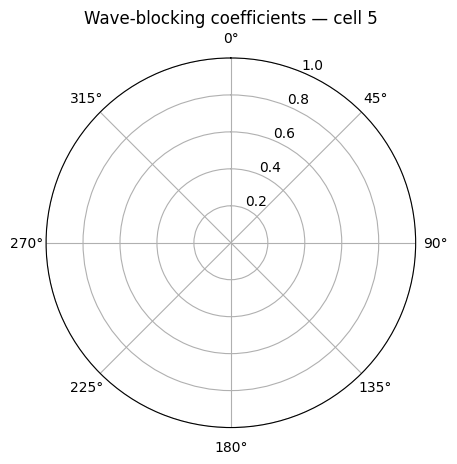

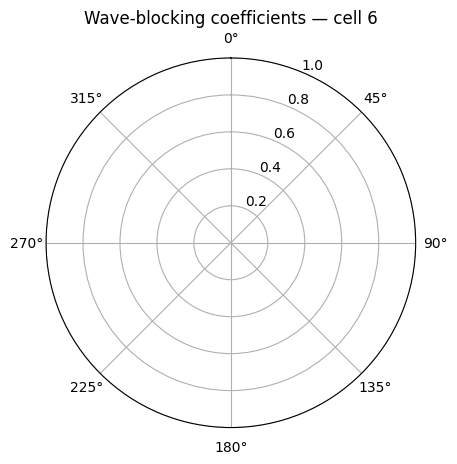

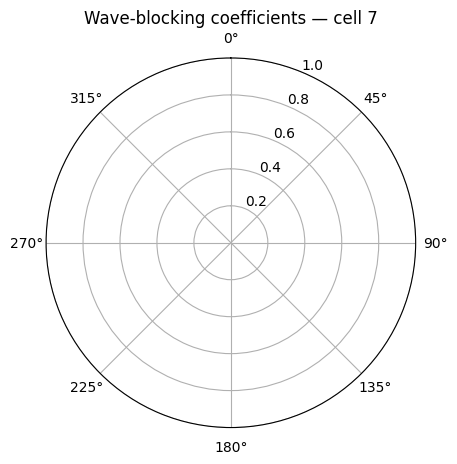

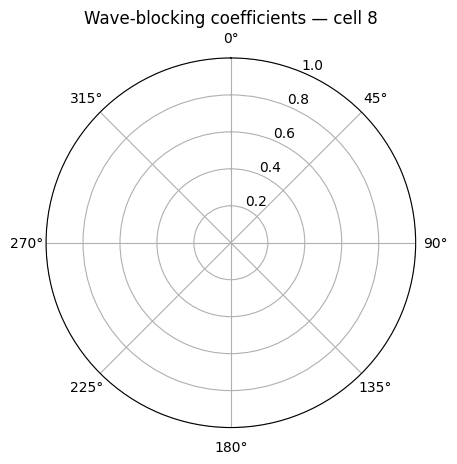

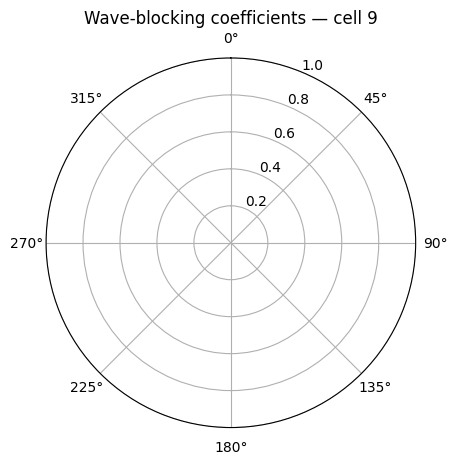

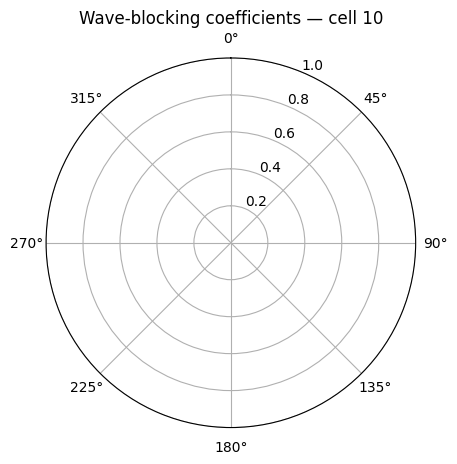

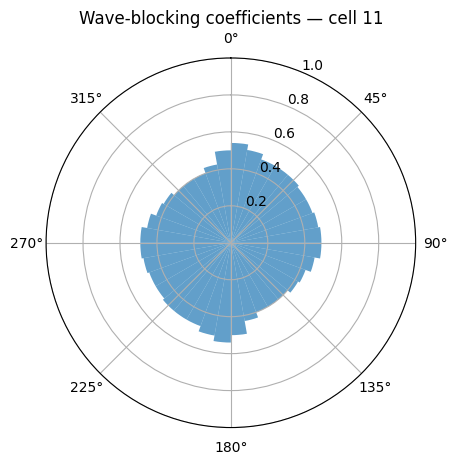

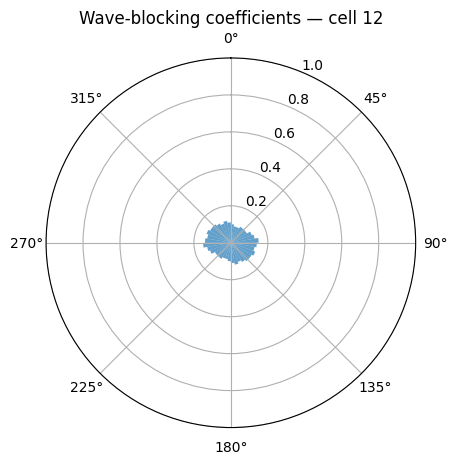

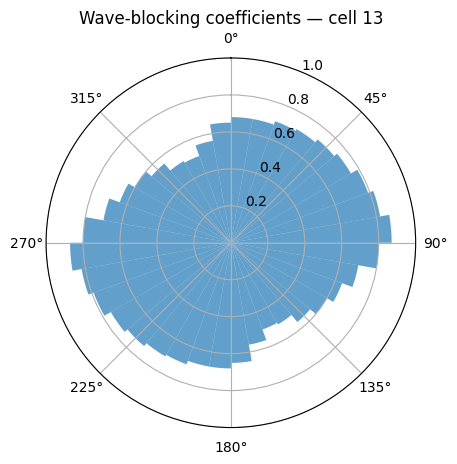

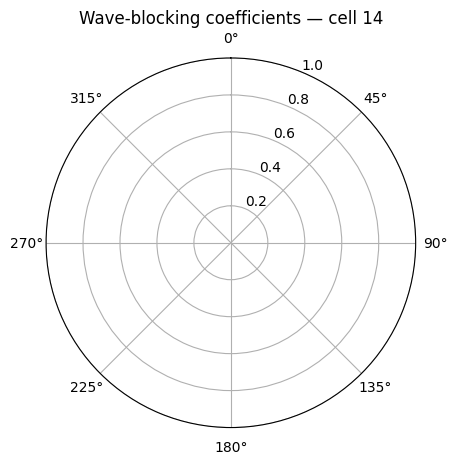

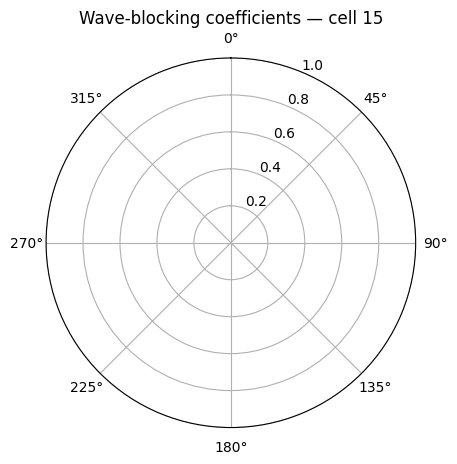

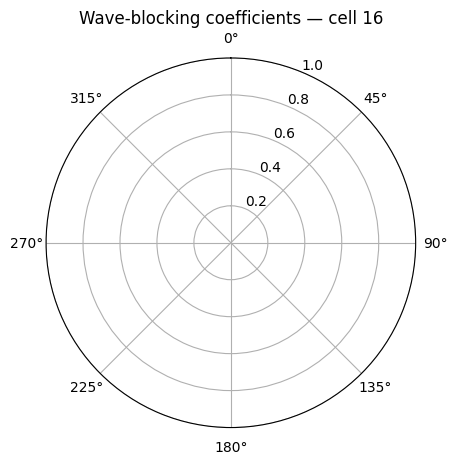

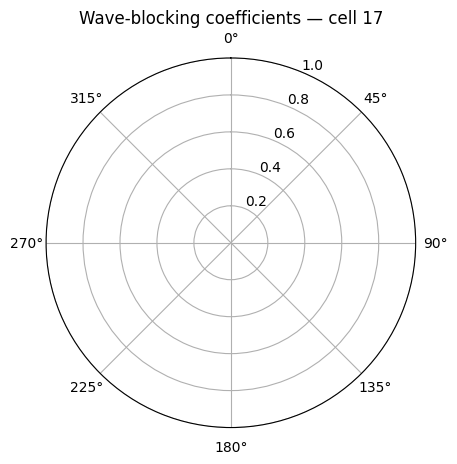

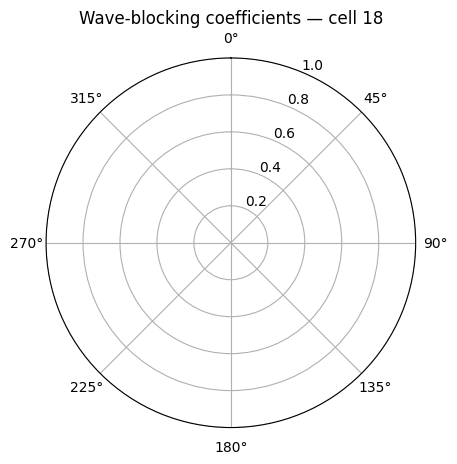

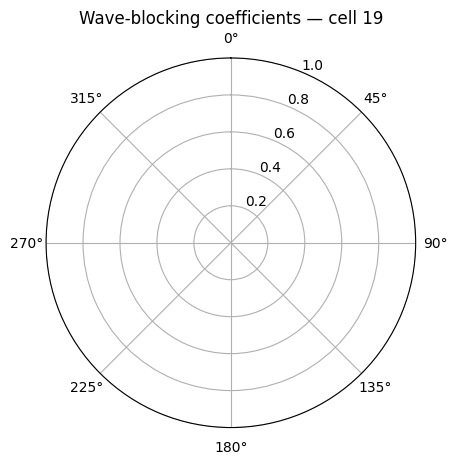

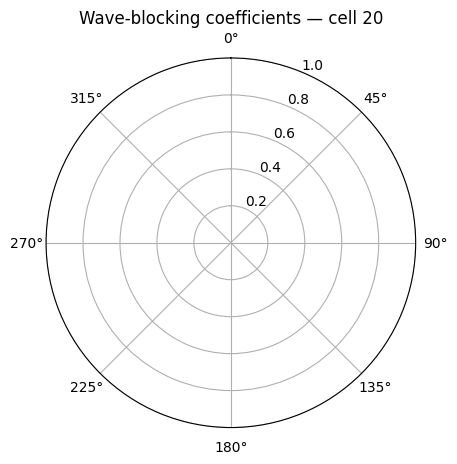

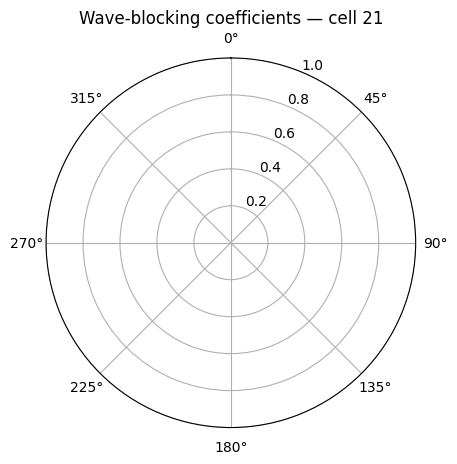

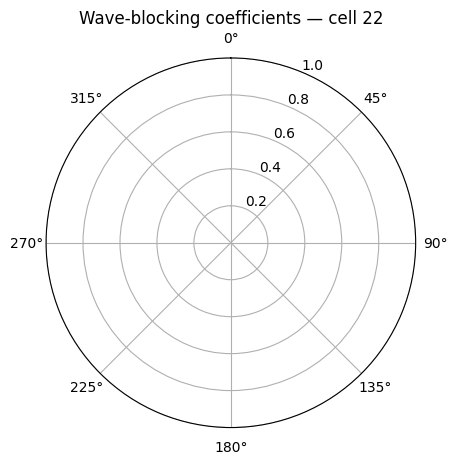

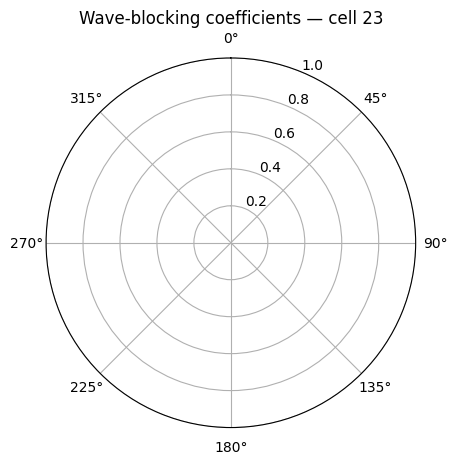

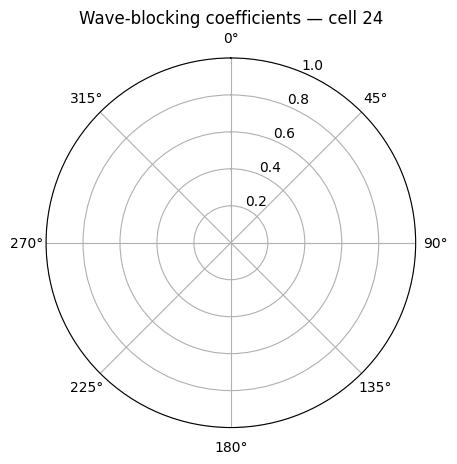

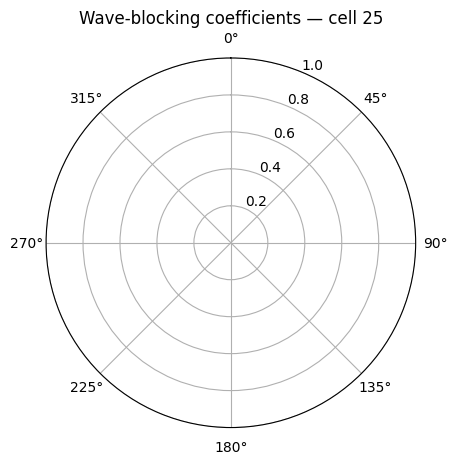

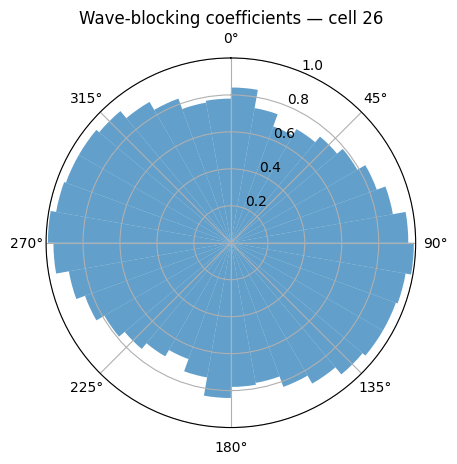

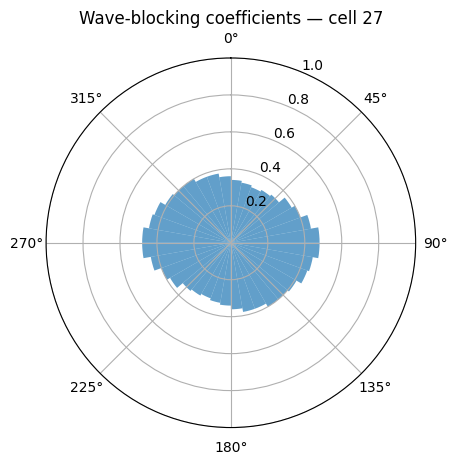

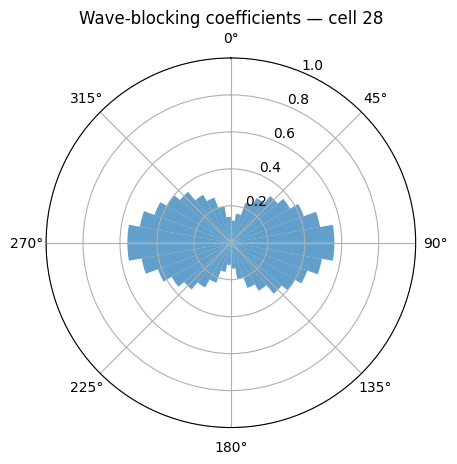

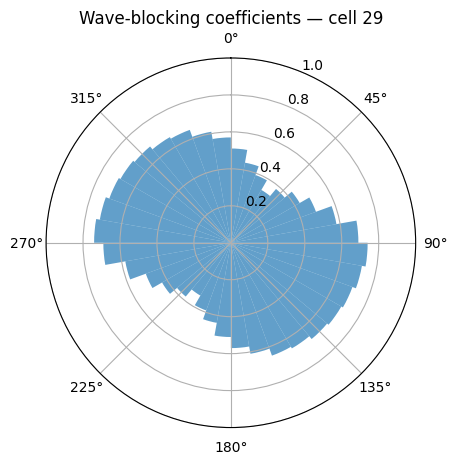

In [18]:
for i in range(30):
    hw.wave_blocking.plot(cell_idx =i)

2026-04-10 09:26:35,359 - hydromt.data_catalog.data_catalog - data_catalog - WARNING - overwriting data source 'caribbean_2022_mean.tif' with provider user and version _UNSPECIFIED_.
2026-04-10 09:26:35,361 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading caribbean_2022_mean.tif RasterDataset data from p:\11212696-fhics-bes\0_data\destination_earth\caribbean_2022_mean.tif
2026-04-10 09:26:36,479 - hydromt.data_catalog.adapters.rasterdataset - rasterdataset - WARNING - Dataset [-70.5, 11.0, -59.5, 19.0] does not fully cover bbox [-75.000, 7.000, -54.000, 22.000]
2026-04-10 09:26:36,482 - hydromt.data_catalog.data_catalog - data_catalog - WARNING - overwriting data source 'gebco_2024_n30.0_s0.0_w-80.0_e-40.0.tif' with provider user and version _UNSPECIFIED_.
2026-04-10 09:26:36,483 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco_2024_n30.0_s0.0_w-80.0_e-40.0.tif RasterDataset data from c:\data\HurryWave\gebco_2024_n30.0_s0.0_w-80.0

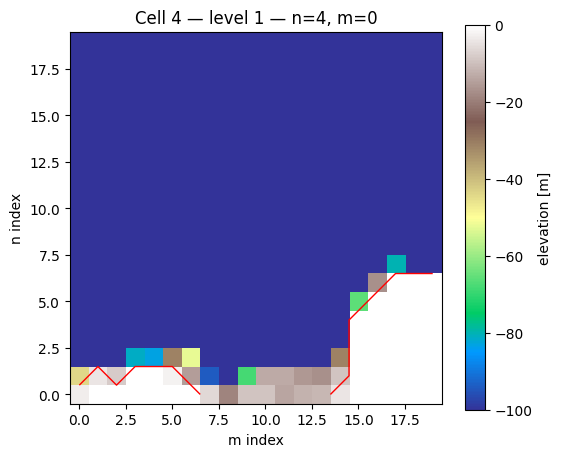

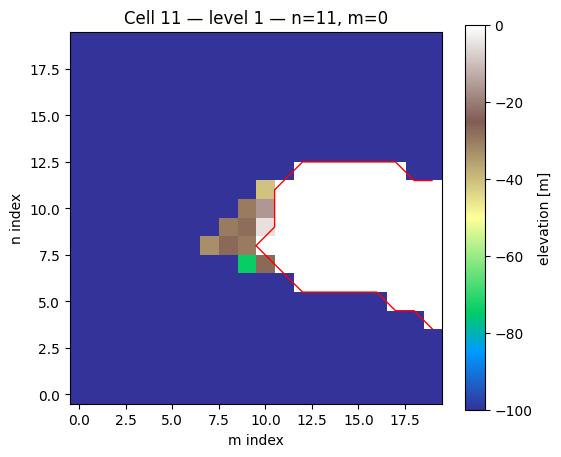

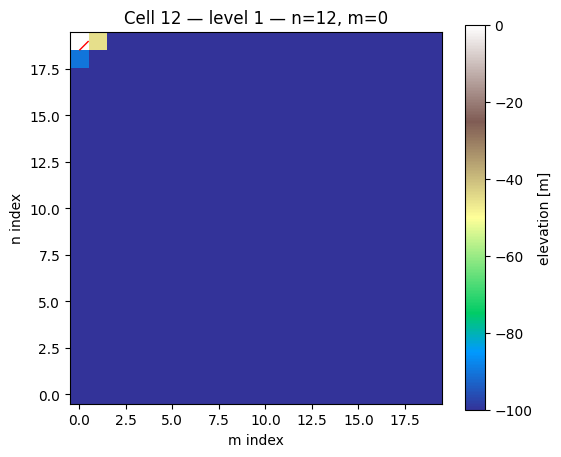

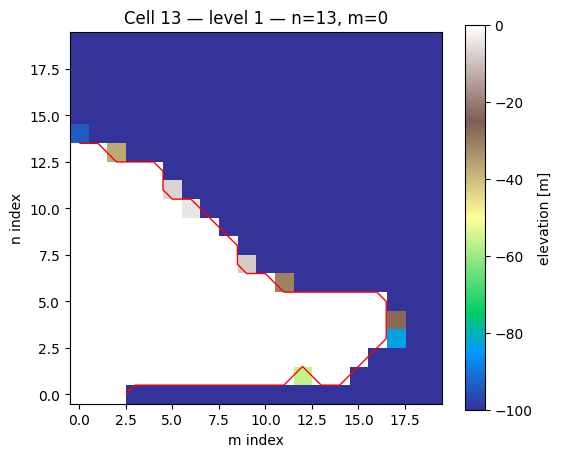

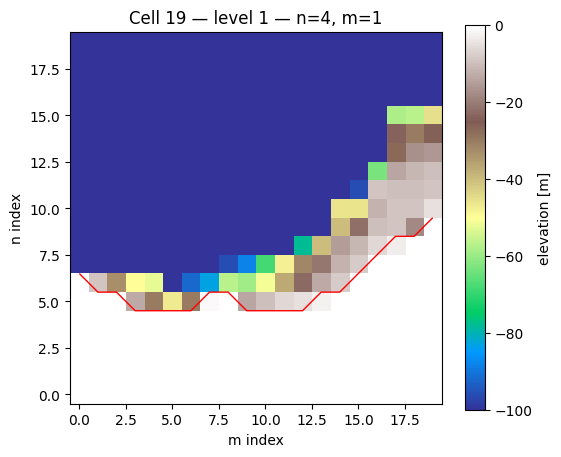

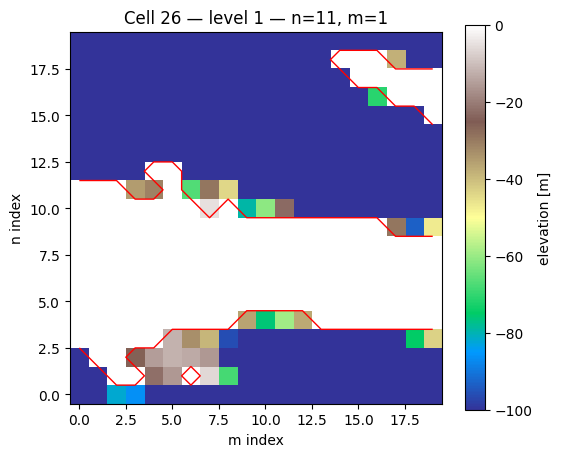

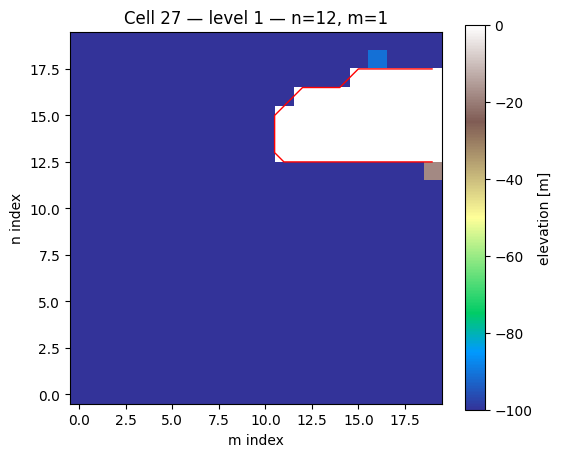

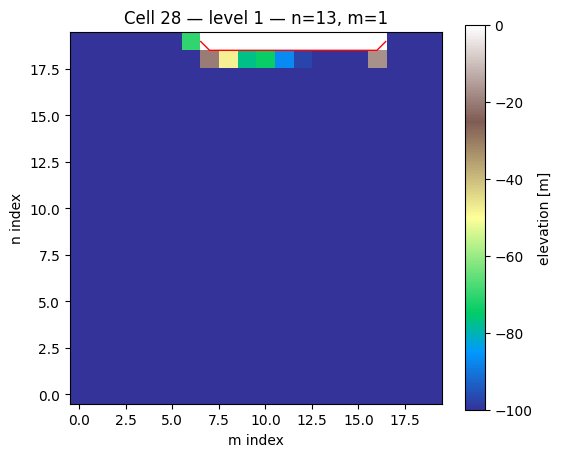

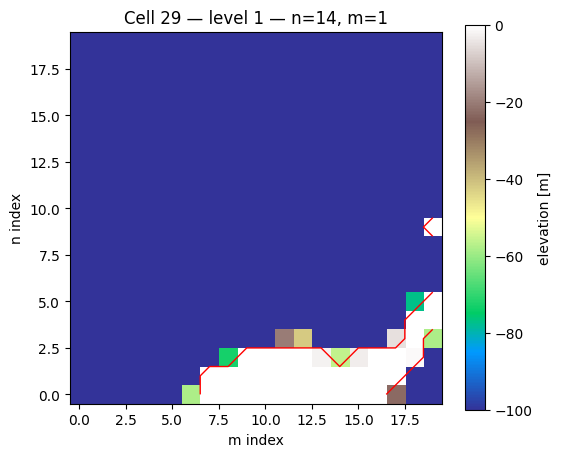

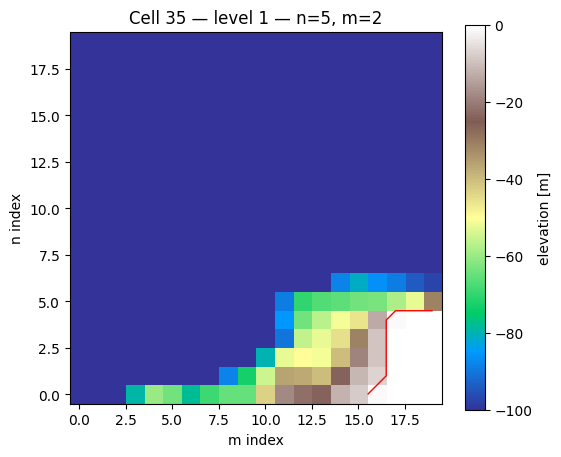

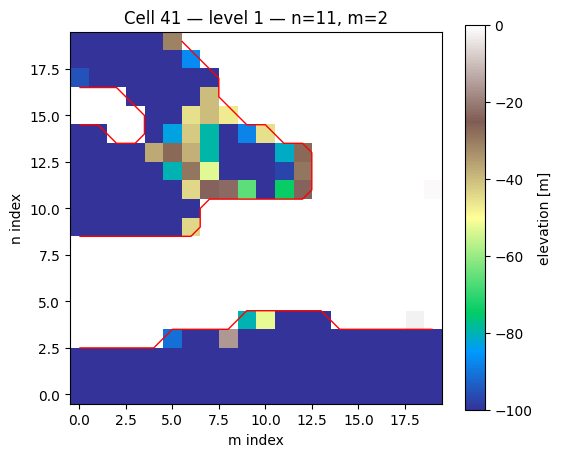

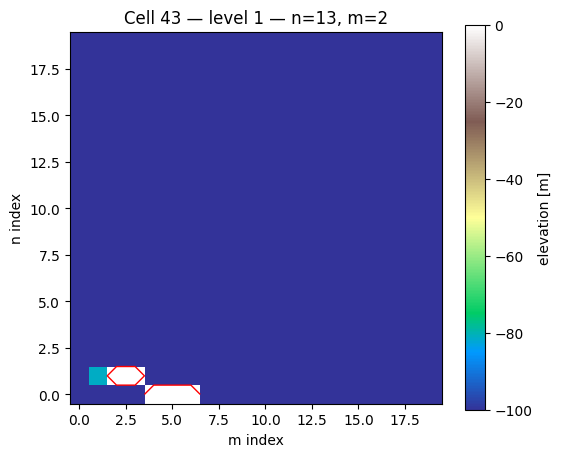

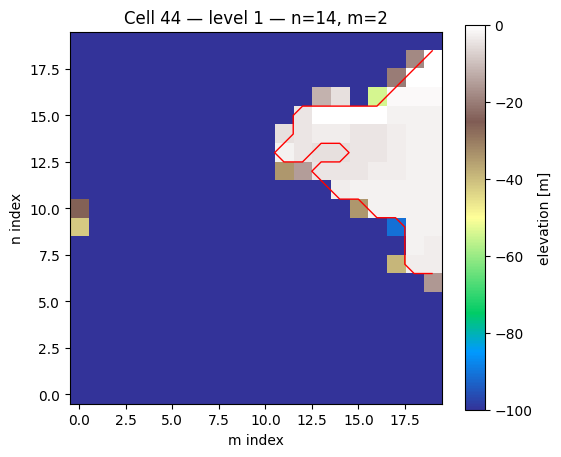

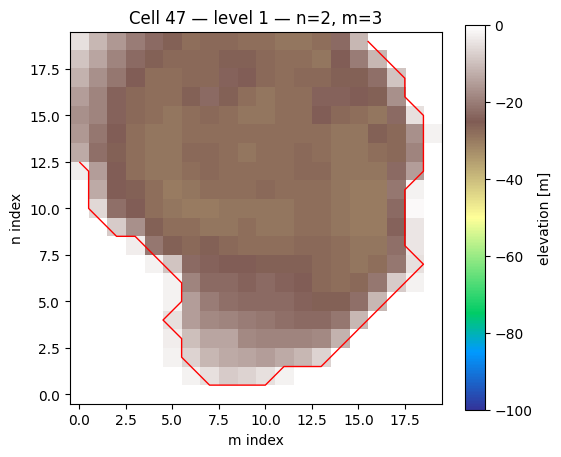

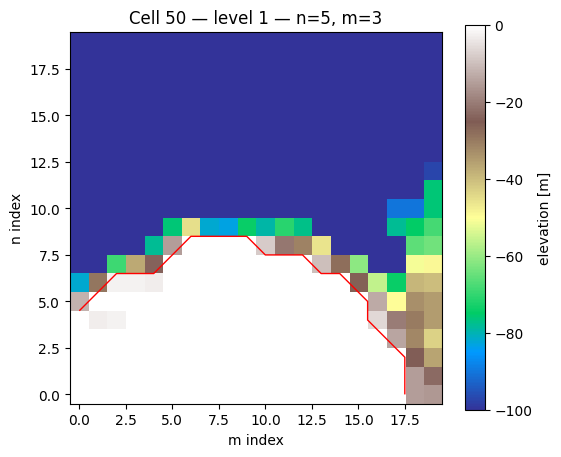

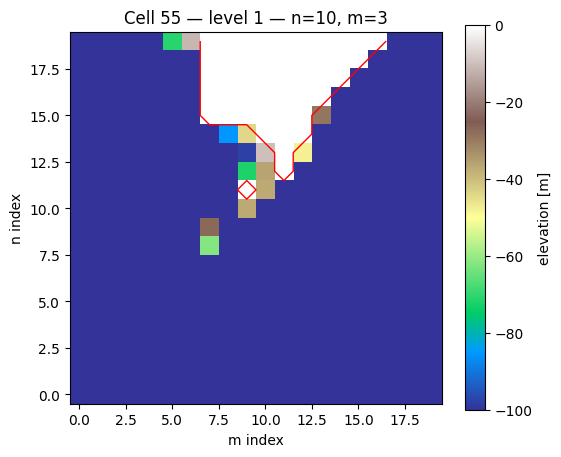

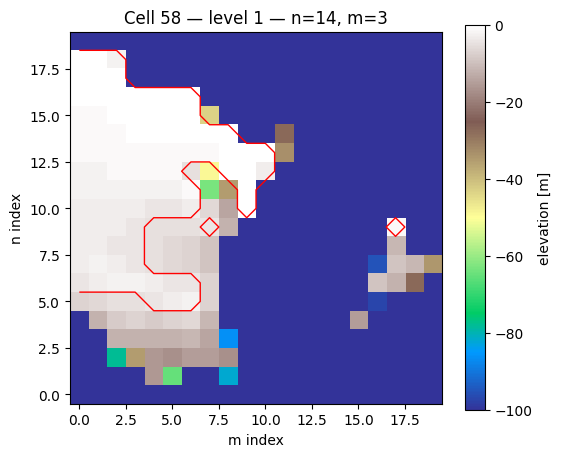

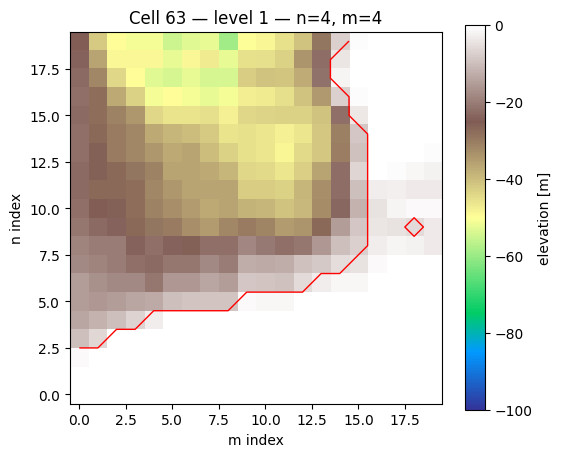

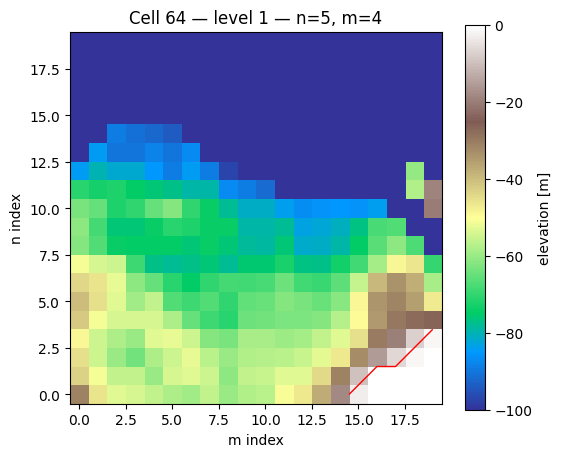

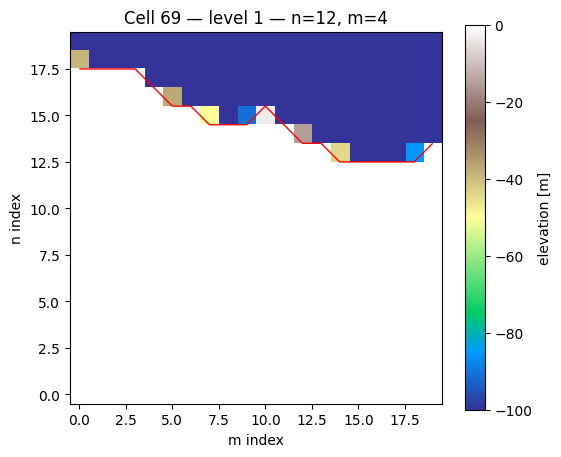

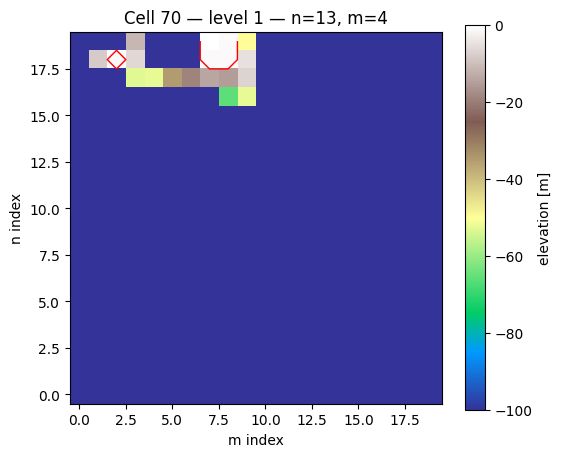

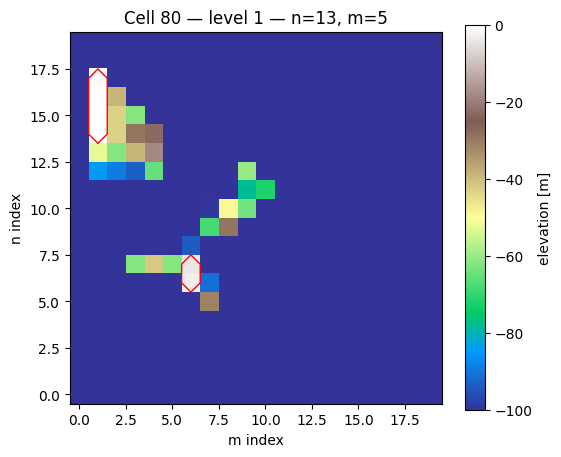

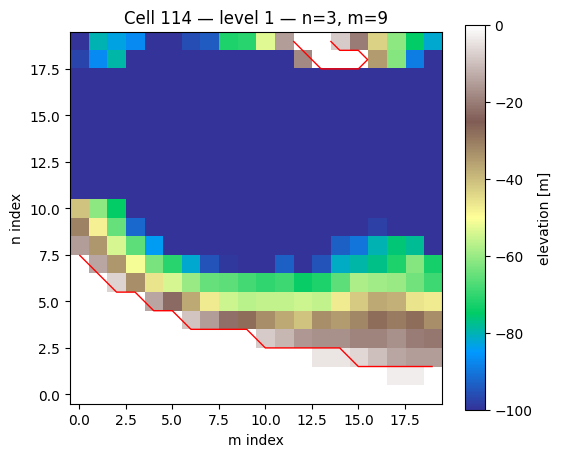

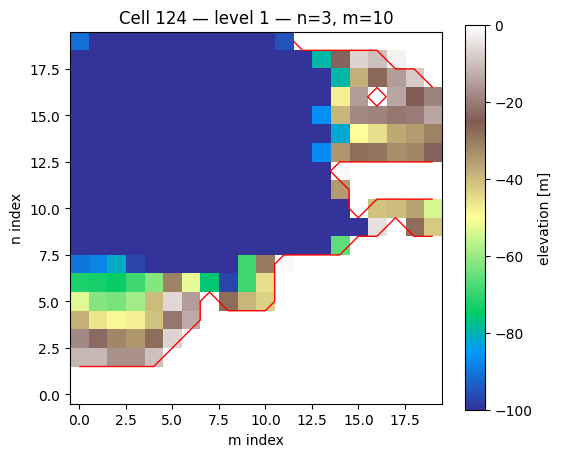

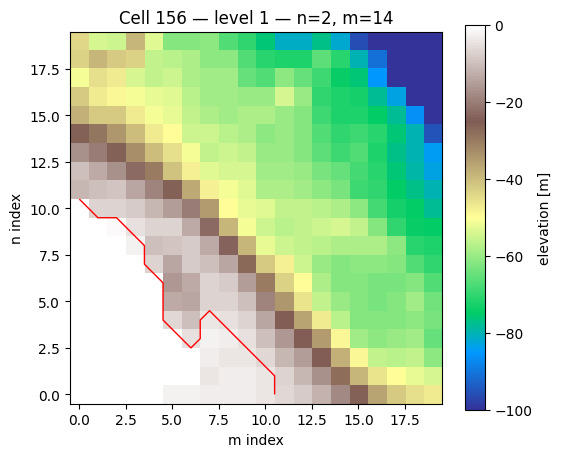

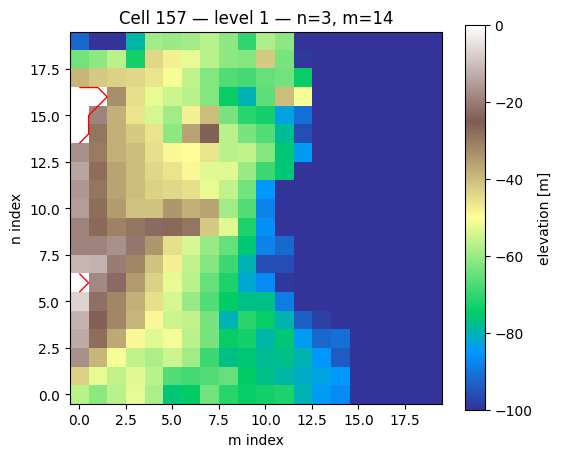

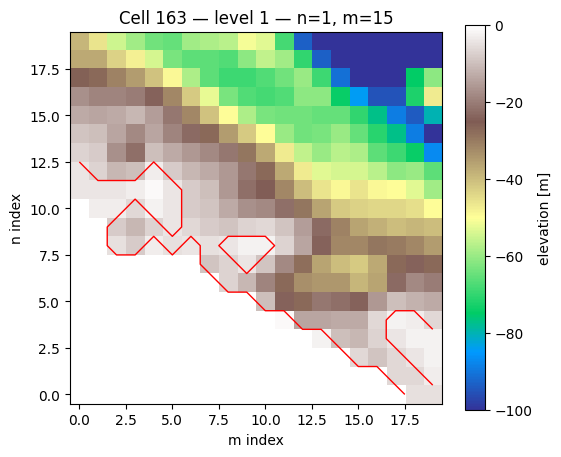

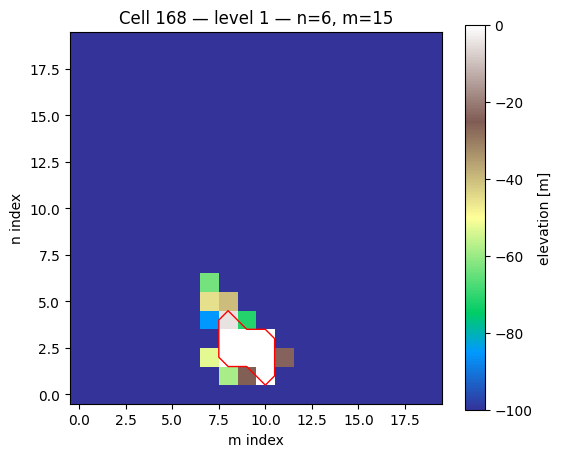

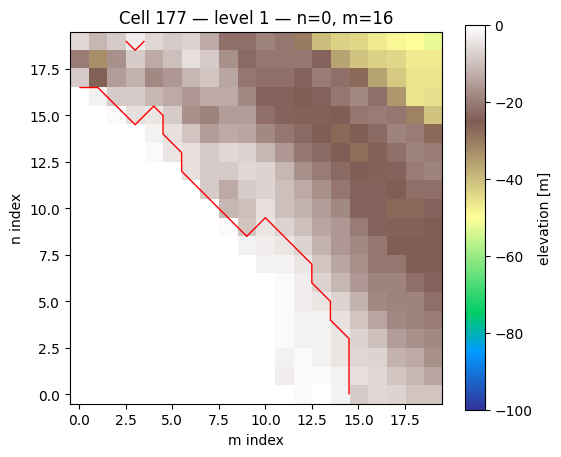

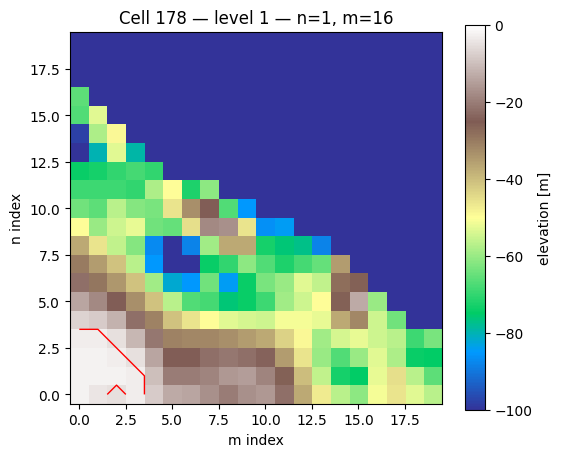

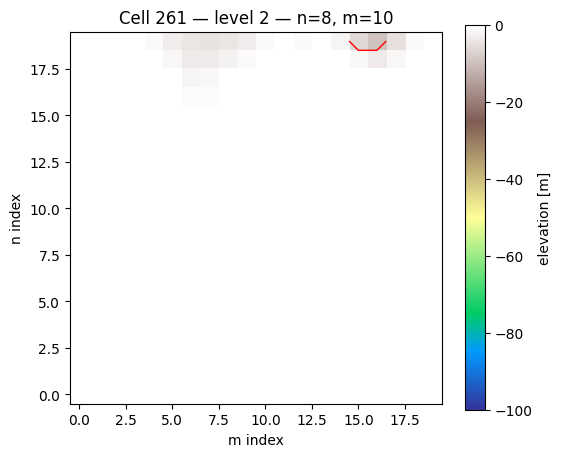

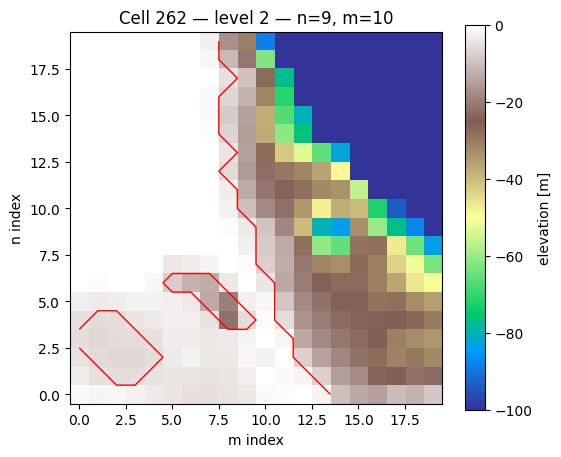

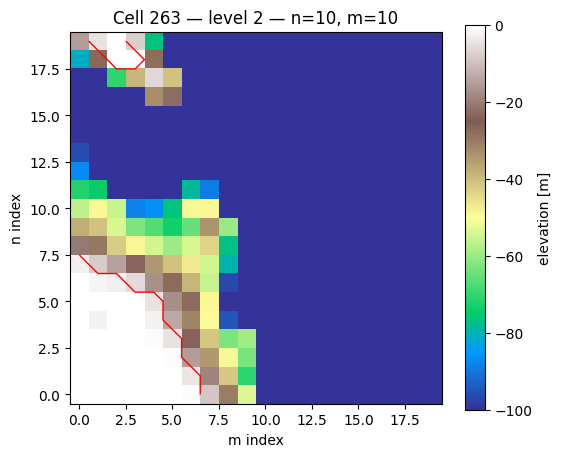

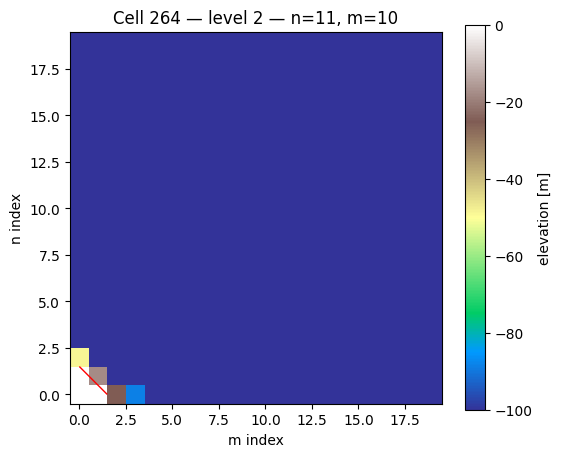

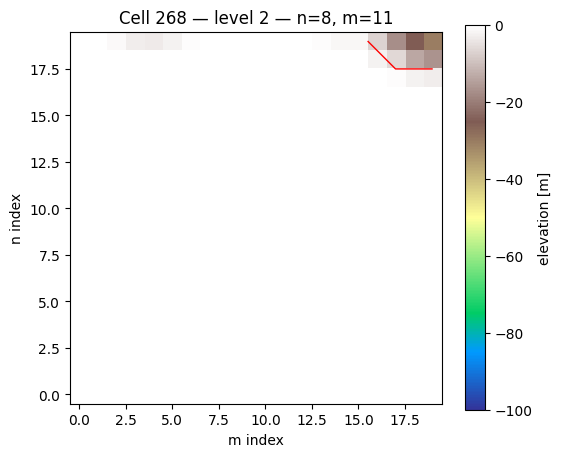

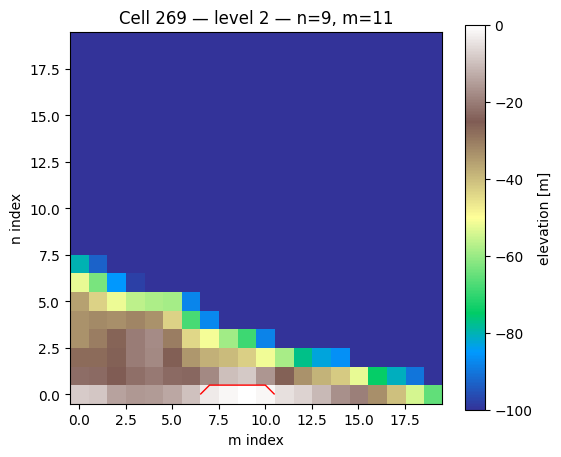

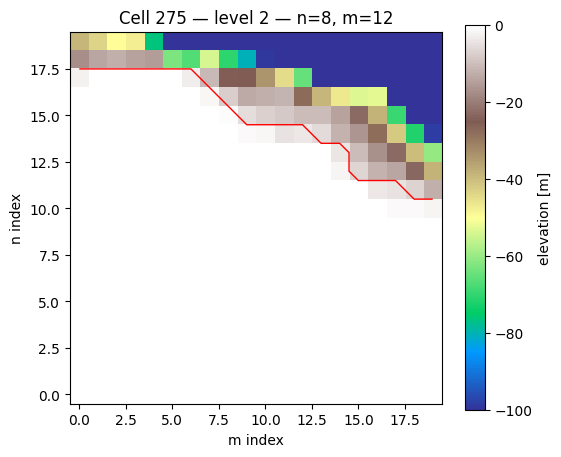

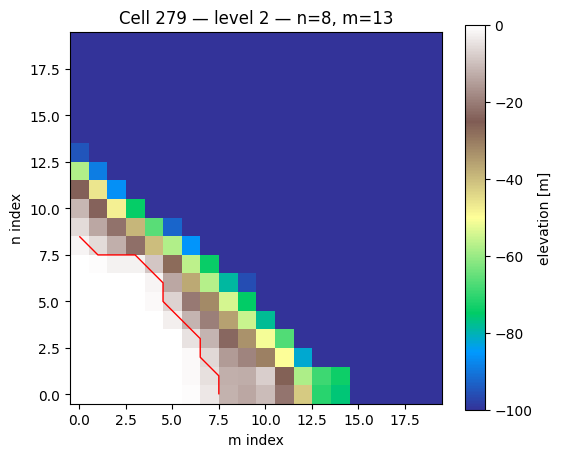

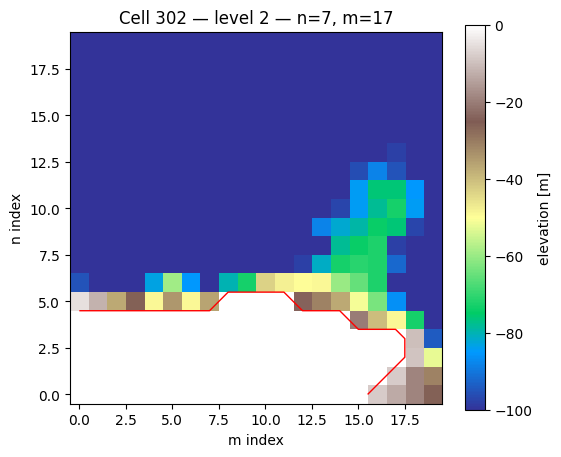

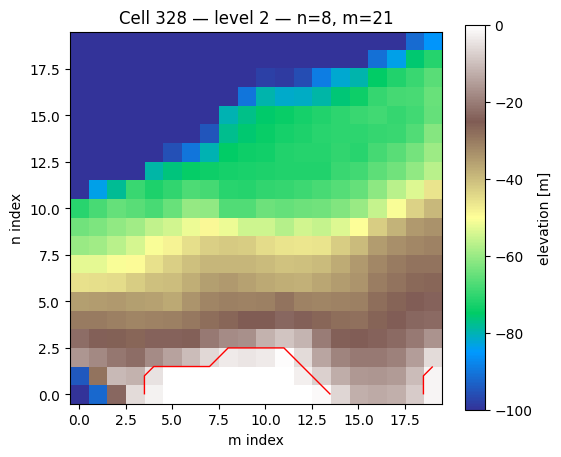

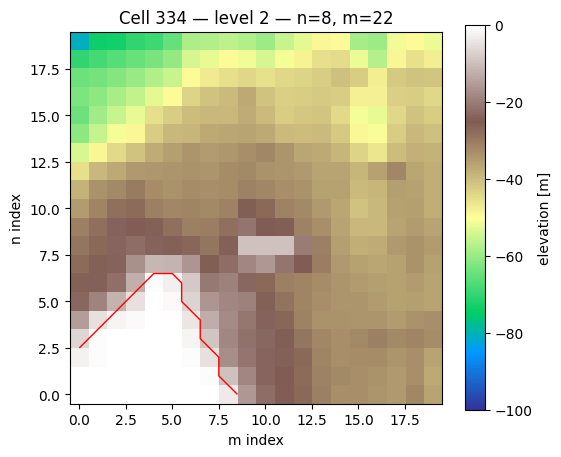

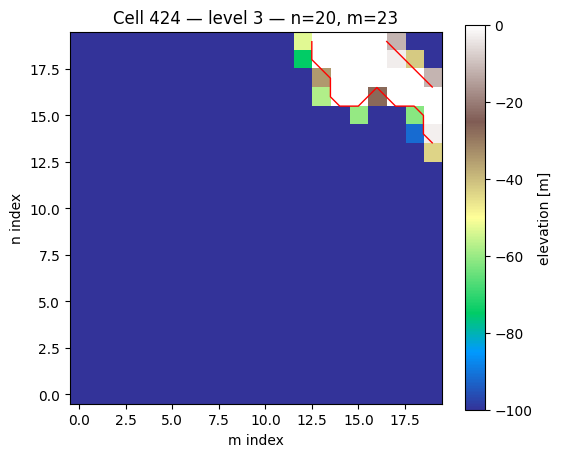

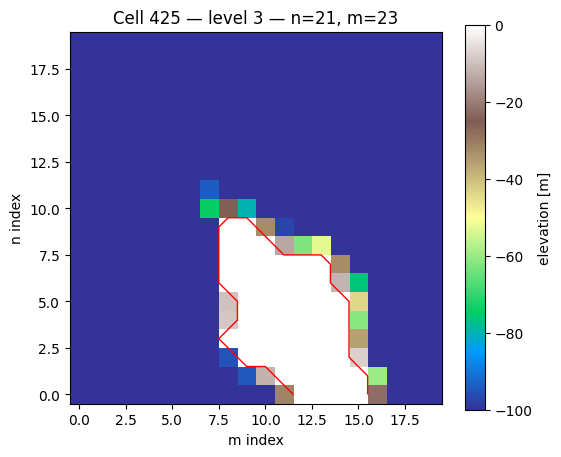

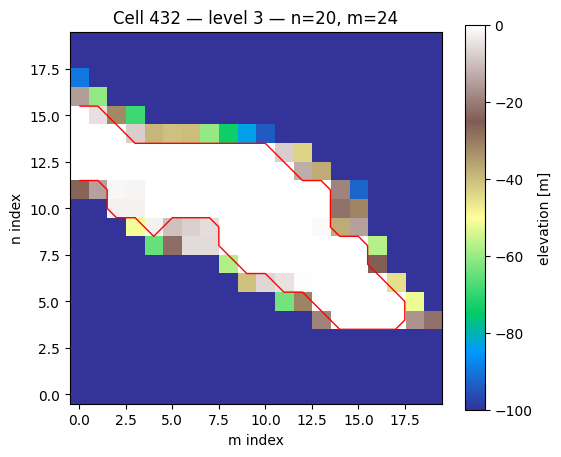

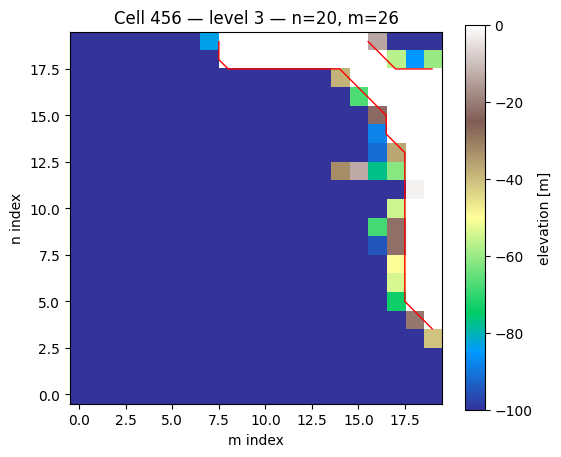

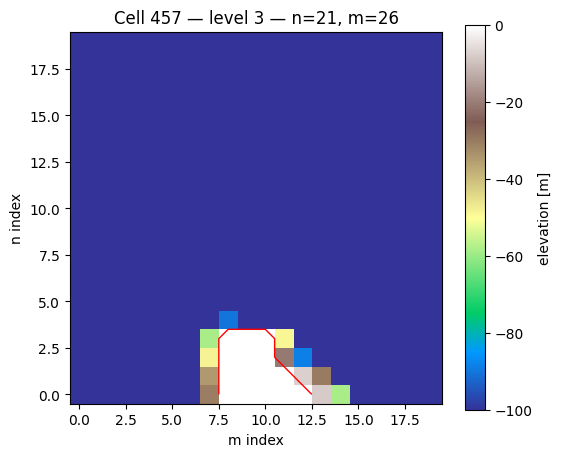

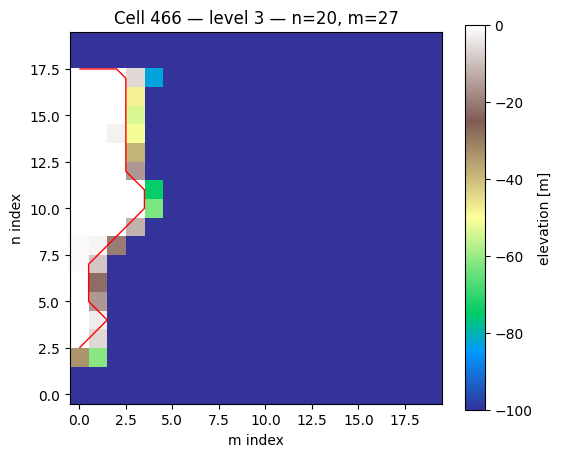

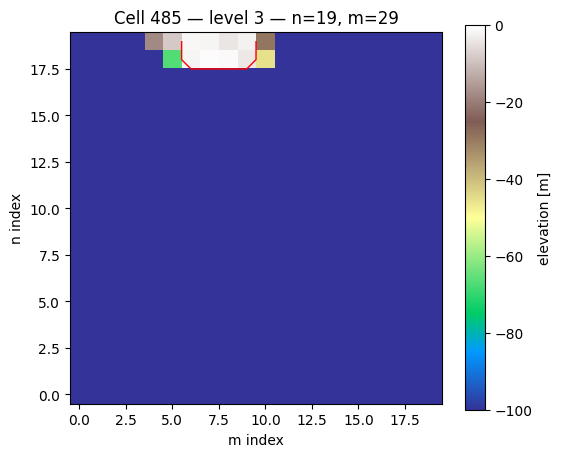

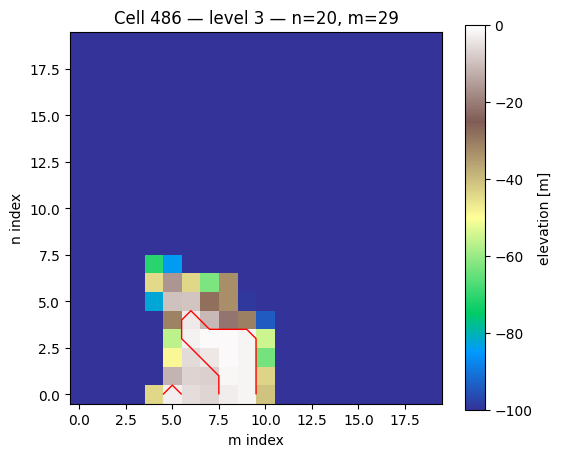

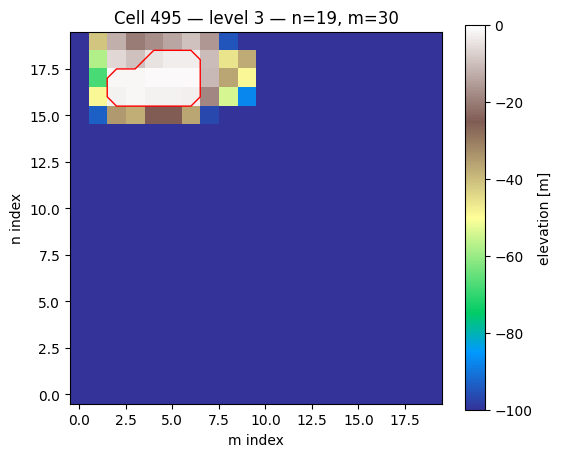

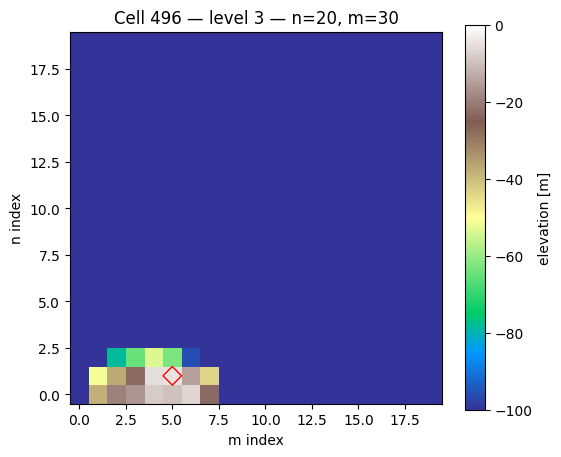

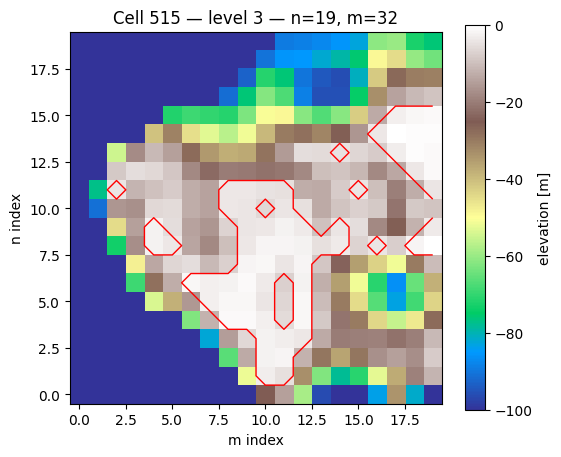

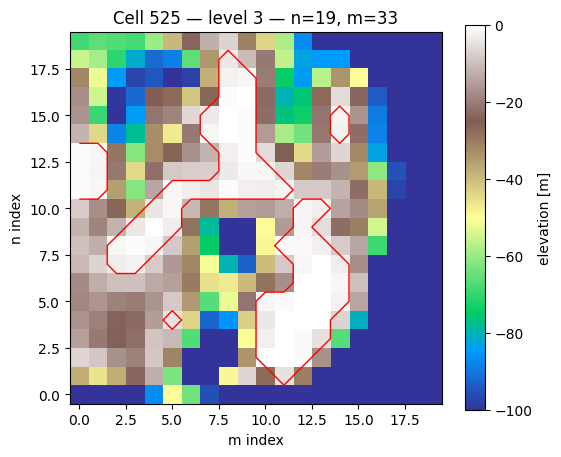

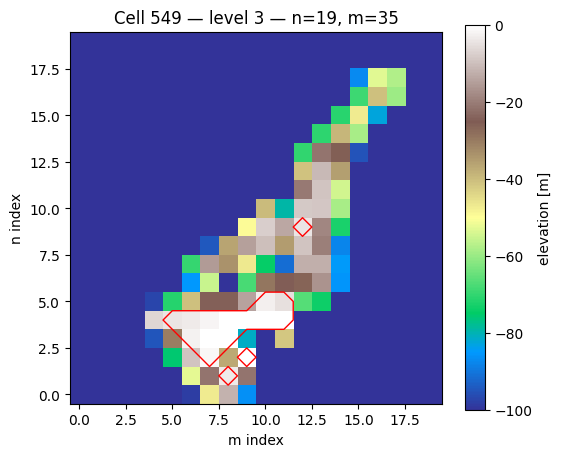

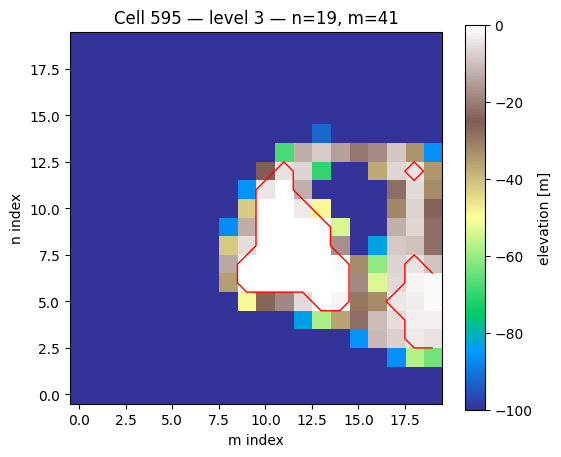

2026-04-10 09:26:46,198 - hydromt.hydromt_hurrywave.components.quadtree.wave_blocking - wave_blocking - INFO - Wave-blocking: 55 cells with obstacles above threshold.


In [12]:
hw.wave_blocking.create(
    elevation_list=elevation_list,
    quiet=False
)

## Write model to disk

In [ ]:
hw.write()